# Classification Tree Analysis (CTA-style) for Incident AAN

This notebook fits a **classification tree (CART / CTA-style)** to predict **future incident AAN** during follow-up among participants **free of AAN at baseline**.

Important software note: â€œCTAâ€ in the strict sense is often implemented in **R** (e.g., `rpart` with `cp`, `minsplit`, `minbucket`). This notebook uses **Python / scikit-learn CART** with closely corresponding controls (`ccp_alpha`, `min_samples_split`, `min_samples_leaf`) to operationalize the same analysis plan in a Colab-friendly way.

In [1]:
import pandas as pd
import numpy as np
import os
from collections.abc import Iterable
from typing import List
# --- mount (safe) ---
import urllib.request
from pathlib import Path

BASE_URL = "https://raw.githubusercontent.com/FelixZhan/AtyAN/main/"
HELPER_FILES = [
    "requirements.txt",
    "AAN-ONSET-MERGED.csv",
]

DATA_FILE_PREFERRED = "AAN-ONSET-MERGED.csv"
DATA_FILE_FALLBACK = "BP1234-ONSET.csv"

for filename in HELPER_FILES:
    dest = Path(filename)
    if dest.exists():
        print(f"{filename} already present, skipping download.")
        continue
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(f"{BASE_URL}{filename}", dest)

data_candidates = [DATA_FILE_PREFERRED, DATA_FILE_FALLBACK]
data_file = None
for cand in data_candidates:
    if Path(cand).exists():
        data_file = cand
        break

if data_file is None:
    data_file = DATA_FILE_FALLBACK
    try:
        print(f"{DATA_FILE_PREFERRED} and {DATA_FILE_FALLBACK} not found locally; attempting to download {data_file} from GitHub.")
        urllib.request.urlretrieve(f"{BASE_URL}{data_file}", data_file)
    except Exception as exc:
        raise RuntimeError(
            f"Could not find {DATA_FILE_PREFERRED} locally and download of {data_file} failed; "
            "place the dataset in this folder and re-run."
        ) from exc

print(f"Using dataset: {data_file}")

def cols_exist(df: pd.DataFrame, cols: Iterable[str]) -> List[str]:
    return [c for c in cols if c in df.columns]

Using dataset: AAN-ONSET-MERGED.csv


In [2]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import math

# Toggle BRF components on/off
RUN_BRF = True

# from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Multiple imputation (MICE / IterativeImputer)
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.base import clone

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm

# ---- Multiple-imputation controls ----
# NOTE: MI is used for evaluation/pooling; reducing M speeds things up a lot.
MI_M = 3
MI_BASE_SEED = 42

def make_mice_imputer(*, random_state: int, sample_posterior: bool):
    return IterativeImputer(
        random_state=random_state,
        sample_posterior=sample_posterior,
        max_iter=10,
        initial_strategy="median",
        skip_complete=True,
    )

def _norm_sf(z: float) -> float:
    # Survival function for standard normal via erfc; avoids SciPy dependency.
    return 0.5 * math.erfc(z / math.sqrt(2.0))

def mi_cross_val_predict_proba(estimator, X, y, *, cv, m: int = MI_M, base_seed: int = MI_BASE_SEED, n_jobs: int = -1):
    """Average CV predicted probabilities across m multiple imputations (posterior draws)."""
    probs_m = []
    for k in range(m):
        est_k = clone(estimator)
        # If this is a Pipeline with an 'imputer' step, vary the imputer RNG per imputation.
        if hasattr(est_k, "get_params"):
            params = est_k.get_params(deep=True)
            if "imputer" in params or any(p.startswith("imputer__") for p in params):
                try:
                    est_k.set_params(
                        imputer=make_mice_imputer(random_state=base_seed + k, sample_posterior=True)
                    )
                except Exception:
                    # Fallback: set step params directly if the imputer object is already present
                    try:
                        est_k.set_params(imputer__random_state=base_seed + k, imputer__sample_posterior=True)
                    except Exception:
                        pass
        probs = cross_val_predict(est_k, X, y, cv=cv, method="predict_proba", n_jobs=n_jobs)[:, 1]
        probs_m.append(probs)
    return np.mean(np.vstack(probs_m), axis=0)

def pooled_logit_or_stats_single_feature(X: pd.DataFrame, y: pd.Series, feature: str, *, m: int = MI_M, base_seed: int = MI_BASE_SEED):
    """
    Fit statsmodels Logit on m multiply-imputed versions of a single-feature design; pool beta/SE (Rubin).
    Returns OR, 95% CI, and (normal-approx) p-value; NaNs if insufficient successful fits.
    """
    X_feat = X[[feature]].copy()
    betas = []
    vars_ = []
    for k in range(m):
        imp = make_mice_imputer(random_state=base_seed + k, sample_posterior=True)
        Xi = pd.DataFrame(imp.fit_transform(X_feat), index=X_feat.index, columns=X_feat.columns)
        X_sm = sm.add_constant(Xi, has_constant="add")
        try:
            res = sm.Logit(y, X_sm).fit(disp=False)
            beta = float(res.params.get(feature, np.nan))
            var = float(res.cov_params().loc[feature, feature]) if feature in res.params.index else np.nan
            if np.isfinite(beta) and np.isfinite(var) and var > 0:
                betas.append(beta)
                vars_.append(var)
        except Exception:
            continue
    if len(betas) < 2:
        return {"odds_ratio": np.nan, "p_value": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    betas = np.asarray(betas, dtype=float)
    vars_ = np.asarray(vars_, dtype=float)
    m_eff = betas.size
    beta_bar = float(betas.mean())
    W = float(vars_.mean())
    B = float(betas.var(ddof=1))
    T = W + (1.0 + 1.0 / m_eff) * B
    se = math.sqrt(T) if T > 0 else float("nan")
    if not np.isfinite(se) or se <= 0:
        return {"odds_ratio": np.nan, "p_value": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    z = beta_bar / se
    p = 2.0 * _norm_sf(abs(z))
    zcrit = 1.959963984540054
    ci_low = beta_bar - zcrit * se
    ci_high = beta_bar + zcrit * se
    return {
        "odds_ratio": float(np.exp(beta_bar)),
        "p_value": float(p),
        "ci_low": float(np.exp(ci_low)),
        "ci_high": float(np.exp(ci_high)),
    }

## Imports and shared setup

In [3]:
COND_MAP = {
    "peer delivered": "BP",
    "ebody": "BP",
    "clincian delivered": "BP",
    "clinician delivered": "BP",
    "diss. (bp)": "BP",
    "exp writing": "BP",
    "control/video control": "Control",
    "healthy weight": "Healthy Weight",
}

COND_CANONICAL = {
    "BP": "BP",
    "Control": "Control",
    "Healthy Weight": "Healthy Weight",
}


def clean_and_encode_condition(df: pd.DataFrame) -> pd.DataFrame:
    if "study_cond" not in df.columns:
        raise KeyError("Missing 'study_cond' column; use dataset with condition labels.")

    cond_raw = df["study_cond"]
    if cond_raw.isna().any() or cond_raw.astype(str).str.strip().eq("").any():
        raise ValueError("Found missing/blank entries in 'study_cond'; expected none.")

    cond_norm = cond_raw.astype(str).str.strip().str.lower()
    cond_clean = cond_norm.map(COND_MAP)

    if cond_clean.isna().any():
        bad_vals = sorted(cond_raw.loc[cond_clean.isna()].unique())
        raise ValueError(f"Unmapped 'study_cond' values: {bad_vals}")

    df = df.copy()
    df["cond_clean"] = cond_clean.map(COND_CANONICAL).astype("category")
    df["cond_bp"] = (df["cond_clean"] == "BP").astype(int)
    df["cond_hw"] = (df["cond_clean"] == "Healthy Weight").astype(int)
    return df

## Candidate Classification Trees for Manuscript Figure

This section mirrors the baseline-feature setup in `AtyAN_UnivariateModels.ipynb` and defines baseline AAN exactly as `w1ONSET-FULL`. It fits two CTA-style figure trees on the same rare-event analytic sample: a 6-terminal-node primary manuscript tree and a 7-terminal-node sensitivity tree. Both display raw node incidence (`cases / n`) in each node. Internal-validation metrics are handled separately in the repeated-CV section below.

The tree figures are drawn in a narrow paper-style vertical layout intended to resemble a stepwise filter, with branch-specific incidence shown in each node and gray rounded terminal nodes.


Aim 2 analytic N: 1918
Minority-class cases: 59
Majority-class non-cases: 1859
Observed incidence: 3.08%
Baseline AAN exclusion rule: exclude w1ONSET-FULL == 1
Manuscript tree profile:
- cta_primary: {'criterion': 'gini', 'class_weight': None, 'min_samples_leaf': 20, 'min_samples_split': 20, 'max_depth': 5, 'max_leaf_nodes': 6, 'ccp_alpha': 0.0, 'random_state': 42}
Primary profile retained in globals for validation/bootstrapping: cta_primary
Descriptive full-data tree imputation: deterministic chained-equations imputation for the descriptive full-data refit
CTA-style primary manuscript tree (6 terminal nodes) | realized internal splits: 5 | leaves: 6
Descriptive separation statistic: F(1, 1916) = 101.95
Apparent full-data classification rate: 0.969
Saved manuscript-style tree figure: aan_tree_cta_primary_manuscript.png
Recommended caption: CTA-style primary manuscript tree (6 terminal nodes). Classification tree for incident AAN.
Leaf-node incidence summary (saved to aan_tree_leaf_inci

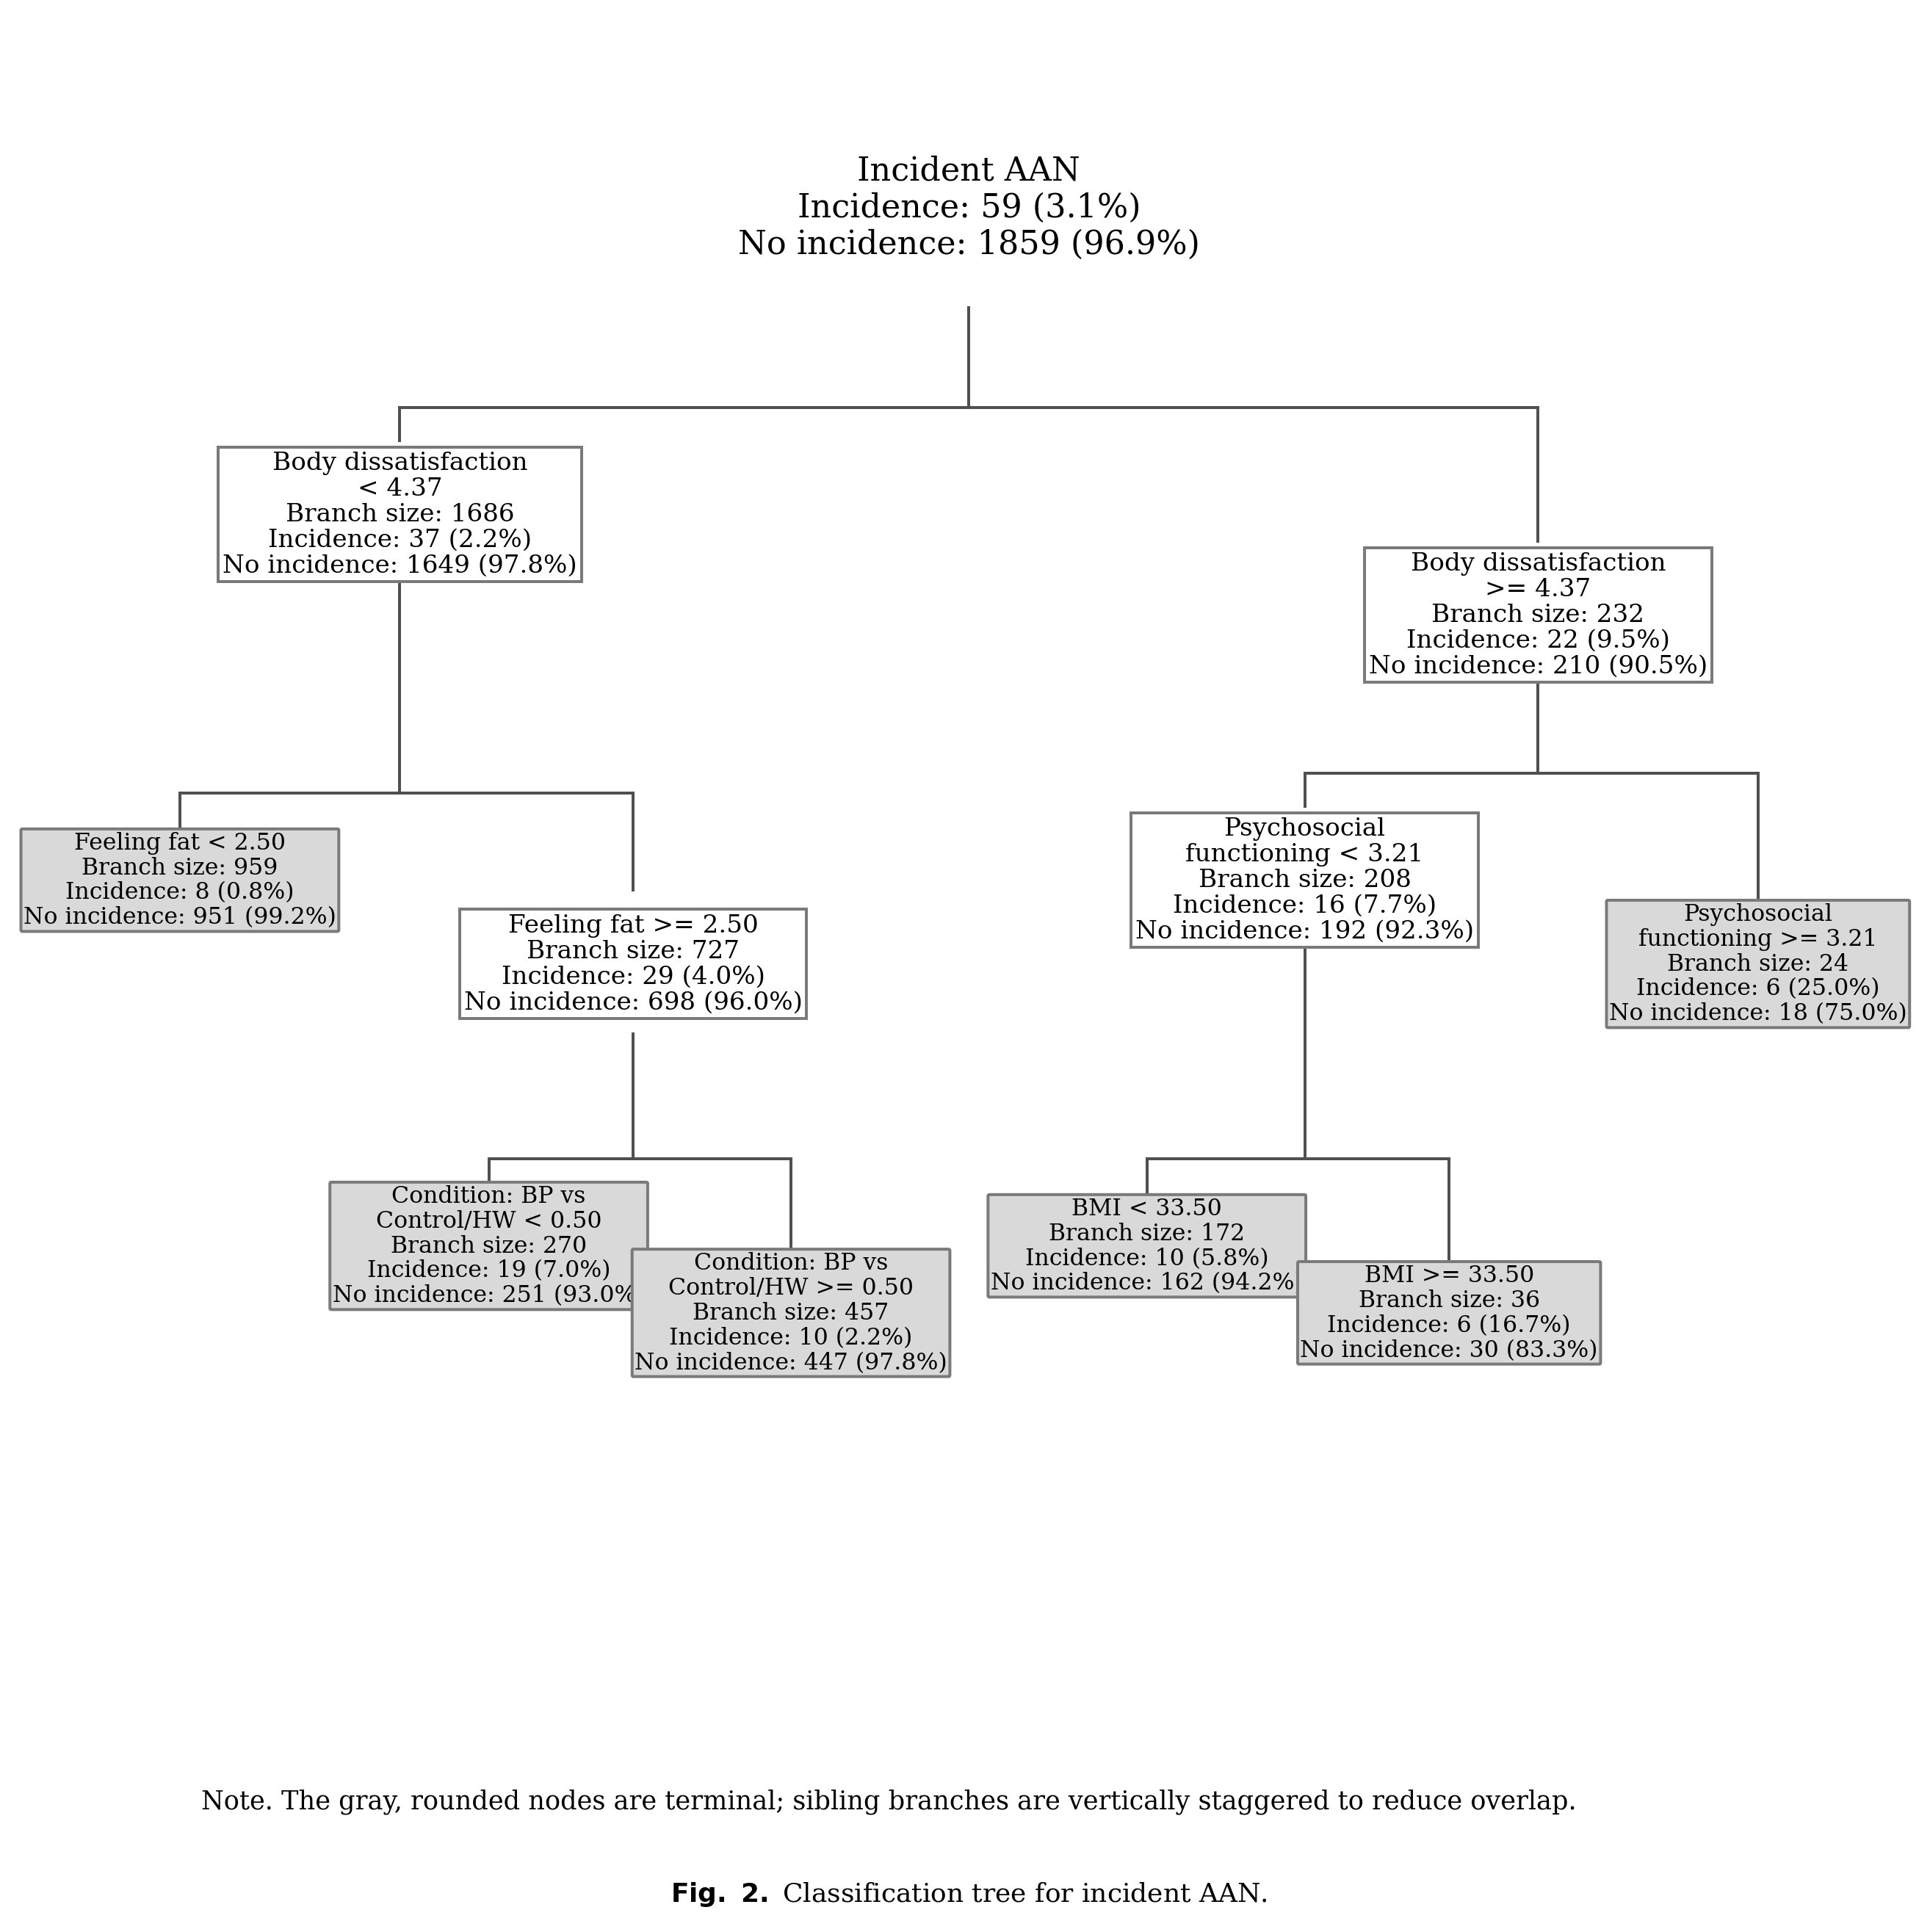

node,n,cases,incidence
4,24,6,0.250000
10,36,6,0.166667
7,270,19,0.070370
9,172,10,0.058140
8,457,10,0.021882
5,959,8,0.008342


node,parent_node,branch,depth,x_center,y_center,is_terminal,condition_text,branch_size_line,incidence_line,nonincidence_line
0,NaN,root,0,0.500,0.890,False,Incident AAN,,Incidence: 59 (3.1%),No incidence: 1859 (96.9%)
1,0.0,left,1,0.161,0.707,False,Body dissatisfaction | < 4.37,Branch size: 1686,Incidence: 37 (2.2%),No incidence: 1649 (97.8%)
2,0.0,right,1,0.839,0.647,False,Body dissatisfaction | >= 4.37,Branch size: 232,Incidence: 22 (9.5%),No incidence: 210 (90.5%)
5,1.0,left,2,0.030,0.488,True,Feeling fat < 2.50,Branch size: 959,Incidence: 8 (0.8%),No incidence: 951 (99.2%)
6,1.0,right,2,0.300,0.438,False,Feeling fat >= 2.50,Branch size: 727,Incidence: 29 (4.0%),No incidence: 698 (96.0%)
3,2.0,left,2,0.700,0.488,False,Psychosocial | functioning < 3.21,Branch size: 208,Incidence: 16 (7.7%),No incidence: 192 (92.3%)
4,2.0,right,2,0.970,0.438,True,Psychosocial | functioning >= 3.21,Branch size: 24,Incidence: 6 (25.0%),No incidence: 18 (75.0%)
7,6.0,left,3,0.214,0.270,True,Condition: BP vs | Control/HW < 0.50,Branch size: 270,Incidence: 19 (7.0%),No incidence: 251 (93.0%)
8,6.0,right,3,0.394,0.230,True,Condition: BP vs | Control/HW >= 0.50,Branch size: 457,Incidence: 10 (2.2%),No incidence: 447 (97.8%)
9,3.0,left,3,0.606,0.270,True,BMI < 33.50,Branch size: 172,Incidence: 10 (5.8%),No incidence: 162 (94.2%)


profile,label,n_leaves,internal_splits,max_depth_realized,onset_positive_leaves,max_leaf_incidence,f_stat,classification_rate
cta_primary,CTA-style primary manuscript tree (6 terminal nodes),6,5,3,6,0.25,101.949821,0.969239


In [6]:
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_text
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import textwrap
from pathlib import Path

RISK_SUFFIXES = ["tii", "bs", "dres", "socf", "dep", "intbmi"]
PRODROMAL_FEATURE_NAMES = ["BE", "CB", "WSO", "FEAR", "FAT", "LEB"]
ONSET_WEIGHT_LABEL = "mBMI"
BASELINE_AAN_COLUMN = "w1ONSET-FULL"
TRUTHY_STRINGS = {"TRUE", "T", "YES", "Y", "1", "PRESENT"}
FALSY_STRINGS = {"FALSE", "F", "NO", "N", "0", "ABSENT"}

FEATURE_LABELS = {
    "w1bs": "Body dissatisfaction",
    "w1dep": "Negative affect",
    "w1dres": "Dieting",
    "w1intbmi": "BMI",
    "w1socf": "Psychosocial functioning",
    "w1tii": "Thin-ideal internalization",
    "BE_w1": "Binge eating",
    "CB_w1": "Compensatory behaviors",
    "FAT_w1": "Feeling fat",
    "FEAR_w1": "Fear of weight gain",
    "LEB_w1": "Lower-than-expected BMI",
    "WSO_w1": "Weight/shape overvaluation",
    "cond_bp": "Condition: BP vs Control/HW",
    "cond_hw": "Condition: Healthy Weight vs Control/BP",
}

TREE_PARAM_OPTIONS = {
    "cta_primary": {
        "criterion": "gini",
        "class_weight": None,
        "min_samples_leaf": 20,
        "min_samples_split": 20,
        "max_depth": 5,
        "max_leaf_nodes": 6,
        "ccp_alpha": 0.0,
        "random_state": 42,
    },
}
TREE_LABELS = {
    "cta_primary": "CTA-style primary manuscript tree (6 terminal nodes)",
}
TREE_FIGURE_LAYOUTS = {
    "cta_primary": {
        "figsize": (7.6, 8.8),
        "dpi": 320,
        "node_fontsize": 7.7,
        "leaf_fontsize": 7.1,
        "root_fontsize": 10.0,
        "note_fontsize": 7.9,
        "caption_fontsize": 8.1,
        "internal_pad": 0.17,
        "leaf_pad": 0.11,
    },
}
PRIMARY_TREE_PROFILE = "cta_primary"
TREE_LAYOUT_MODE = "filter_vertical"
ROOT_LABEL = "Incident AAN"
TERMINAL_FACE = "#d9d9d9"
INTERNAL_FACE = "white"
NODE_EDGE = "#7a7a7a"
CONNECTOR_COLOR = "#505050"


def english_name(feature: str) -> str:
    return FEATURE_LABELS.get(feature, feature)


def _coerce_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def _coerce_boolean(series: pd.Series) -> pd.Series:
    if series is None:
        return pd.Series(pd.NA, dtype="boolean")
    as_str = series.astype(str).str.strip().str.upper()
    out = pd.Series(pd.NA, index=series.index, dtype="boolean")
    out[as_str.isin(TRUTHY_STRINGS)] = True
    out[as_str.isin(FALSY_STRINGS)] = False
    numeric = pd.to_numeric(series, errors="coerce")
    out[numeric.notna()] = numeric[numeric.notna()] != 0
    return out


def engineer_wave_prodromals(work: pd.DataFrame, wave: int) -> list:
    cols = []
    base = pd.Series(np.nan, index=work.index)

    be_src = f"w{wave}ede1a"
    work[f"BE_w{wave}"] = _coerce_numeric(work.get(be_src, base))
    cols.append(f"BE_w{wave}")

    cb_cols = [
        c
        for c in [f"w{wave}ed8a", f"w{wave}ed9a", f"w{wave}ed10a", f"w{wave}ed11a"]
        if c in work.columns
    ]
    if cb_cols:
        cb_block = work[cb_cols].apply(_coerce_numeric)
        work[f"CB_w{wave}"] = cb_block.max(axis=1, skipna=True)
        work.loc[cb_block.notna().sum(axis=1) == 0, f"CB_w{wave}"] = np.nan
    else:
        work[f"CB_w{wave}"] = np.nan
    cols.append(f"CB_w{wave}")

    work[f"WSO_w{wave}"] = _coerce_numeric(work.get(f"w{wave}ed15a", base))
    work[f"FEAR_w{wave}"] = _coerce_numeric(work.get(f"w{wave}ed17a", base))
    work[f"FAT_w{wave}"] = _coerce_numeric(work.get(f"w{wave}ed19a", base))
    cols.extend([f"WSO_w{wave}", f"FEAR_w{wave}", f"FAT_w{wave}"])

    mbmi_pct = _coerce_numeric(work.get(f"w{wave}mbmi_pct", base))
    work[f"LEB_w{wave}"] = np.clip(90.0 - mbmi_pct, 0, None) / 90.0
    cols.append(f"LEB_w{wave}")
    return cols


def build_predictors(df: pd.DataFrame):
    work = df.copy()
    risk_cols = []
    for suffix in RISK_SUFFIXES:
        col = f"w1{suffix}"
        if col in work.columns:
            work[col] = _coerce_numeric(work[col])
            risk_cols.append(col)
    prod_cols = engineer_wave_prodromals(work, wave=1)
    features = list(dict.fromkeys(risk_cols + prod_cols))
    cond_cols = [c for c in ["cond_bp", "cond_hw"] if c in work.columns]
    features = list(dict.fromkeys(features + cond_cols))
    return work, features


def build_onset_dataset(
    df: pd.DataFrame,
    onset_weight_label: str = ONSET_WEIGHT_LABEL,
) -> pd.DataFrame:
    mask_w1_onset = _coerce_boolean(df.get(BASELINE_AAN_COLUMN, pd.Series(np.nan, index=df.index))).fillna(False)
    subset = df.loc[~mask_w1_onset].copy()

    onset_pattern = re.compile(
        rf"^w([1-6])ONSET-FULL-{re.escape(onset_weight_label)}$",
        re.IGNORECASE,
    )
    onset_cols = [c for c in subset.columns if onset_pattern.match(c)]
    if not onset_cols:
        raise ValueError(f"No ONSET-FULL-{onset_weight_label} columns found in the dataset.")

    onset_block = subset[onset_cols].apply(_coerce_numeric).fillna(0)
    subset["aan_onset_anywave"] = onset_block.gt(0).any(axis=1).astype(int)
    return subset


def anova_f_stat_by_group(values: np.ndarray, groups: np.ndarray):
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups, dtype=int)
    keep = np.isfinite(values)
    values = values[keep]
    groups = groups[keep]
    unique_groups = np.unique(groups)
    n_groups = int(unique_groups.size)
    n_total = int(values.size)
    if n_groups < 2 or n_total <= n_groups:
        return np.nan, np.nan, np.nan

    grand_mean = float(values.mean())
    ss_between = 0.0
    ss_within = 0.0
    for g in unique_groups:
        vals = values[groups == g]
        if vals.size == 0:
            continue
        mean_g = float(vals.mean())
        ss_between += float(vals.size) * (mean_g - grand_mean) ** 2
        ss_within += float(((vals - mean_g) ** 2).sum())

    df1 = n_groups - 1
    df2 = n_total - n_groups
    if df1 <= 0 or df2 <= 0:
        return np.nan, np.nan, np.nan
    if ss_within <= 0:
        return np.inf, int(df1), int(df2)
    f_stat = (ss_between / df1) / (ss_within / df2)
    return float(f_stat), int(df1), int(df2)


def build_parent_lookup(tree_model):
    tree_ = tree_model.tree_
    parent_lookup = {0: None}
    direction_lookup = {0: None}
    stack = [0]
    while stack:
        node_id = stack.pop()
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]
        if left_id != -1:
            parent_lookup[left_id] = node_id
            direction_lookup[left_id] = "left"
            parent_lookup[right_id] = node_id
            direction_lookup[right_id] = "right"
            stack.extend([left_id, right_id])
    return parent_lookup, direction_lookup


def build_subtree_summaries(tree_model, node_stats):
    tree_ = tree_model.tree_
    summaries = {}

    def walk(node_id: int):
        left_id = tree_.children_left[node_id]
        if left_id == -1:
            incidence = float(node_stats[node_id]["incidence"])
            summaries[node_id] = {
                "internal_nodes": 0,
                "leaf_count": 1,
                "max_leaf_incidence": incidence if np.isfinite(incidence) else 0.0,
                "cases": int(node_stats[node_id]["cases"]),
                "n": int(node_stats[node_id]["n"]),
            }
            return summaries[node_id]

        right_id = tree_.children_right[node_id]
        left_summary = walk(left_id)
        right_summary = walk(right_id)
        summaries[node_id] = {
            "internal_nodes": 1 + left_summary["internal_nodes"] + right_summary["internal_nodes"],
            "leaf_count": left_summary["leaf_count"] + right_summary["leaf_count"],
            "max_leaf_incidence": max(left_summary["max_leaf_incidence"], right_summary["max_leaf_incidence"]),
            "cases": left_summary["cases"] + right_summary["cases"],
            "n": left_summary["n"] + right_summary["n"],
        }
        return summaries[node_id]

    walk(0)
    return summaries


def choose_continuation_child(node_id, tree_model, subtree_summaries):
    tree_ = tree_model.tree_
    left_id = tree_.children_left[node_id]
    right_id = tree_.children_right[node_id]
    if left_id == -1:
        return None, None

    left_is_leaf = bool(tree_.children_left[left_id] == -1)
    right_is_leaf = bool(tree_.children_left[right_id] == -1)
    if left_is_leaf and right_is_leaf:
        return None, None
    if left_is_leaf and not right_is_leaf:
        return right_id, left_id
    if right_is_leaf and not left_is_leaf:
        return left_id, right_id

    def score(child_id: int):
        summary = subtree_summaries[child_id]
        return (
            summary["internal_nodes"],
            summary["max_leaf_incidence"],
            summary["cases"],
            summary["n"],
        )

    continuation_id = max([left_id, right_id], key=score)
    side_id = right_id if continuation_id == left_id else left_id
    return continuation_id, side_id


def compute_tree_positions(tree_model, node_stats, layout_mode: str = TREE_LAYOUT_MODE):
    tree_ = tree_model.tree_
    depths = {}

    def walk_depth(node_id: int, depth: int):
        depths[node_id] = depth
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]
        if left_id != -1:
            walk_depth(left_id, depth + 1)
            walk_depth(right_id, depth + 1)

    walk_depth(0, 0)
    max_depth = max(depths.values()) if depths else 0
    parent_lookup, direction_lookup = build_parent_lookup(tree_model)
    leaf_order = []

    def walk_leaves(node_id: int):
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]
        if left_id == -1:
            leaf_order.append(node_id)
            return
        walk_leaves(left_id)
        walk_leaves(right_id)

    walk_leaves(0)
    leaf_index = {node_id: idx for idx, node_id in enumerate(leaf_order)}
    x_lookup = {}

    def walk_x(node_id: int):
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]
        if left_id == -1:
            x_lookup[node_id] = float(leaf_index[node_id])
        else:
            left_x = walk_x(left_id)
            right_x = walk_x(right_id)
            x_lookup[node_id] = (left_x + right_x) / 2.0
        return x_lookup[node_id]

    walk_x(0)
    max_leaf_index = max(leaf_index.values()) if leaf_index else 0
    if layout_mode == "filter_vertical":
        x_margin = 0.05
        x_span = 0.90
        top_y = 0.89
        bottom_y = 0.25 if max_depth >= 3 else 0.33
    else:
        x_margin = 0.09
        x_span = 0.82
        top_y = 0.87
        bottom_y = 0.30

    positions = {}
    for node_id in range(tree_.node_count):
        if max_leaf_index == 0:
            x_pos = 0.5
        else:
            x_pos = x_margin + x_span * (x_lookup[node_id] / max_leaf_index)
        if max_depth == 0:
            y_pos = top_y
        else:
            y_pos = top_y - (top_y - bottom_y) * (depths[node_id] / max_depth)

        if layout_mode == "filter_vertical" and node_id != 0:
            depth = depths[node_id]
            direction = direction_lookup[node_id]
            direction_sign = 1.0 if direction == "left" else -1.0
            y_offset = max(0.010, 0.030 - 0.005 * (depth - 1))
            outward_sign = -1.0 if x_lookup[node_id] < x_lookup[0] else (1.0 if x_lookup[node_id] > x_lookup[0] else 0.0)
            x_offset = max(0.006, 0.024 - 0.004 * (depth - 1))
            y_pos += direction_sign * y_offset
            x_pos += outward_sign * x_offset

        positions[node_id] = (x_pos, y_pos)
    return positions, depths


def format_threshold(value: float) -> str:
    return f"{float(value):.2f}"


def wrap_condition(feature_label: str, operator: str, threshold: float) -> str:
    rule = f"{feature_label} {operator} {format_threshold(threshold)}"
    return textwrap.fill(rule, width=21, break_long_words=False)


def get_publication_node_components(node_id, tree_model, node_stats, feature_names, parent_lookup, direction_lookup):
    stats = node_stats[node_id]
    n_total = max(stats["n"], 1)
    cases = stats["cases"]
    noncases = stats["n"] - cases
    incidence_pct = 100.0 * cases / n_total
    nonincidence_pct = 100.0 * noncases / n_total

    if node_id == 0:
        return {
            "condition_text": ROOT_LABEL,
            "branch_size_line": "",
            "incidence_line": f"Incidence: {cases} ({incidence_pct:.1f}%)",
            "nonincidence_line": f"No incidence: {noncases} ({nonincidence_pct:.1f}%)",
        }

    parent_id = parent_lookup[node_id]
    direction = direction_lookup[node_id]
    feature_id = tree_model.tree_.feature[parent_id]
    threshold = tree_model.tree_.threshold[parent_id]
    feature_label = english_name(feature_names[feature_id])
    operator = "<" if direction == "left" else ">="
    condition = wrap_condition(feature_label, operator, threshold)
    return {
        "condition_text": condition,
        "branch_size_line": f"Branch size: {stats['n']}",
        "incidence_line": f"Incidence: {cases} ({incidence_pct:.1f}%)",
        "nonincidence_line": f"No incidence: {noncases} ({nonincidence_pct:.1f}%)",
    }


def make_publication_node_label(node_id, tree_model, node_stats, feature_names, parent_lookup, direction_lookup):
    components = get_publication_node_components(
        node_id=node_id,
        tree_model=tree_model,
        node_stats=node_stats,
        feature_names=feature_names,
        parent_lookup=parent_lookup,
        direction_lookup=direction_lookup,
    )
    lines = [components["condition_text"]]
    if components["branch_size_line"]:
        lines.append(components["branch_size_line"])
    lines.extend([components["incidence_line"], components["nonincidence_line"]])
    return "\n".join(lines)


def build_word_box_table(tree_model, node_stats, feature_names):
    positions, depths = compute_tree_positions(tree_model, node_stats)
    parent_lookup, direction_lookup = build_parent_lookup(tree_model)
    tree_ = tree_model.tree_
    rows = []
    for node_id in range(tree_.node_count):
        node_text = make_publication_node_label(
            node_id=node_id,
            tree_model=tree_model,
            node_stats=node_stats,
            feature_names=feature_names,
            parent_lookup=parent_lookup,
            direction_lookup=direction_lookup,
        )
        components = get_publication_node_components(
            node_id=node_id,
            tree_model=tree_model,
            node_stats=node_stats,
            feature_names=feature_names,
            parent_lookup=parent_lookup,
            direction_lookup=direction_lookup,
        )
        x_pos, y_pos = positions[node_id]
        rows.append(
            {
                "node": int(node_id),
                "parent_node": parent_lookup[node_id],
                "branch": "root" if node_id == 0 else direction_lookup[node_id],
                "depth": int(depths[node_id]),
                "x_center": round(float(x_pos), 3),
                "y_center": round(float(y_pos), 3),
                "is_terminal": bool(tree_.children_left[node_id] == -1),
                "condition_text": components["condition_text"].replace("\n", " | "),
                "branch_size_line": components["branch_size_line"],
                "incidence_line": components["incidence_line"],
                "nonincidence_line": components["nonincidence_line"],
                "box_text": node_text.replace("\n", " | "),
            }
        )
    return pd.DataFrame(rows).sort_values(["depth", "x_center", "node"]).reset_index(drop=True)


def draw_publication_tree(
    tree_model,
    node_stats,
    feature_names,
    profile_label,
    figure_layout,
):
    positions, depths = compute_tree_positions(tree_model, node_stats)
    parent_lookup, direction_lookup = build_parent_lookup(tree_model)
    tree_ = tree_model.tree_

    fig, ax = plt.subplots(
        figsize=figure_layout["figsize"],
        dpi=figure_layout["dpi"],
        facecolor="white",
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    for node_id in range(tree_.node_count):
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]
        x_parent, y_parent = positions[node_id]
        if left_id != -1:
            x_left, y_left = positions[left_id]
            x_right, y_right = positions[right_id]
            parent_drop = 0.060 if node_id == 0 else 0.042
            left_rise = 0.032 if tree_.children_left[left_id] == -1 else 0.044
            right_rise = 0.032 if tree_.children_left[right_id] == -1 else 0.044
            parent_anchor_y = y_parent - parent_drop
            left_anchor_y = y_left + left_rise
            right_anchor_y = y_right + right_rise
            bend_y = min(parent_anchor_y - 0.018, max(left_anchor_y, right_anchor_y) + 0.020)
            ax.plot(
                [x_parent, x_parent],
                [parent_anchor_y, bend_y],
                color=CONNECTOR_COLOR,
                lw=0.9,
                zorder=1,
            )
            ax.plot(
                [x_parent, x_left],
                [bend_y, bend_y],
                color=CONNECTOR_COLOR,
                lw=0.9,
                zorder=1,
            )
            ax.plot(
                [x_left, x_left],
                [bend_y, left_anchor_y],
                color=CONNECTOR_COLOR,
                lw=0.9,
                zorder=1,
            )
            ax.plot(
                [x_parent, x_right],
                [bend_y, bend_y],
                color=CONNECTOR_COLOR,
                lw=0.9,
                zorder=1,
            )
            ax.plot(
                [x_right, x_right],
                [bend_y, right_anchor_y],
                color=CONNECTOR_COLOR,
                lw=0.9,
                zorder=1,
            )

    for node_id in range(tree_.node_count):
        is_leaf = bool(tree_.children_left[node_id] == -1)
        x_pos, y_pos = positions[node_id]
        node_text = make_publication_node_label(
            node_id=node_id,
            tree_model=tree_model,
            node_stats=node_stats,
            feature_names=feature_names,
            parent_lookup=parent_lookup,
            direction_lookup=direction_lookup,
        )
        if node_id == 0:
            ax.text(
                x_pos,
                y_pos,
                node_text,
                ha="center",
                va="center",
                fontsize=figure_layout["root_fontsize"],
                fontfamily="serif",
                linespacing=1.2,
                zorder=2,
                clip_on=False,
            )
            continue

        leaf_pad = figure_layout.get("leaf_pad", 0.14)
        internal_pad = figure_layout.get("internal_pad", 0.22)
        node_fontsize = figure_layout.get("leaf_fontsize", figure_layout["node_fontsize"]) if is_leaf else figure_layout["node_fontsize"]
        bbox = {
            "boxstyle": f"round,pad={leaf_pad},rounding_size=0.06" if is_leaf else f"square,pad={internal_pad}",
            "facecolor": TERMINAL_FACE if is_leaf else INTERNAL_FACE,
            "edgecolor": NODE_EDGE,
            "linewidth": 0.9,
        }
        ax.text(
            x_pos,
            y_pos,
            node_text,
            ha="center",
            va="center",
            fontsize=node_fontsize,
            fontfamily="serif",
            linespacing=1.12,
            bbox=bbox,
            zorder=2,
            clip_on=False,
        )

    fig.text(
        0.07,
        0.090,
        "Note. The gray, rounded nodes are terminal; sibling branches are vertically staggered to reduce overlap.",
        ha="left",
        va="center",
        fontsize=figure_layout["note_fontsize"],
        fontfamily="serif",
    )
    fig.text(
        0.50,
        0.045,
        r"$\bf{Fig.\ 2.}$ Classification tree for incident AAN.",
        ha="center",
        va="center",
        fontsize=figure_layout["caption_fontsize"],
        fontfamily="serif",
    )
    fig.subplots_adjust(left=0.03, right=0.97, top=0.95, bottom=0.14)
    return fig, ax


if "raw_df" not in globals():
    raw_df = pd.read_csv(Path(data_file), low_memory=False)

# Match the univariate notebook's baseline-feature setup and baseline AAN rule.
df_with_cond = clean_and_encode_condition(raw_df)
feature_df, base_features = build_predictors(df_with_cond)
dataset = build_onset_dataset(
    feature_df,
    onset_weight_label=ONSET_WEIGHT_LABEL,
)
predictor_cols = [c for c in base_features if c in dataset.columns and not c.endswith("-persistence")]
for cond_col in ["cond_bp", "cond_hw"]:
    if cond_col in dataset.columns and cond_col not in predictor_cols:
        predictor_cols.append(cond_col)

X = dataset[predictor_cols].copy()
y = dataset["aan_onset_anywave"].astype(int)
y_arr = np.asarray(y, dtype=int)

print(f"Aim 2 analytic N: {len(y)}")
print(f"Minority-class cases: {int(y_arr.sum())}")
print(f"Majority-class non-cases: {int((1 - y_arr).sum())}")
print(f"Observed incidence: {float(y_arr.mean()) * 100:.2f}%")
print(f"Baseline AAN exclusion rule: exclude {BASELINE_AAN_COLUMN} == 1")
print("Manuscript tree profile:")
for profile_name, params in TREE_PARAM_OPTIONS.items():
    print(f"- {profile_name}: {params}")
print(f"Primary profile retained in globals for validation/bootstrapping: {PRIMARY_TREE_PROFILE}")

imputer_label = "median imputation fallback"
try:
    plot_imputer = make_mice_imputer(random_state=42, sample_posterior=False)
    X_imp = pd.DataFrame(plot_imputer.fit_transform(X), columns=X.columns, index=X.index)
    imputer_label = "deterministic chained-equations imputation for the descriptive full-data refit"
except Exception:
    plot_imputer = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(plot_imputer.fit_transform(X), columns=X.columns, index=X.index)
print(f"Descriptive full-data tree imputation: {imputer_label}")

tree_results = {}
profile_summaries = []

for profile_name, tree_params in TREE_PARAM_OPTIONS.items():
    profile_label = TREE_LABELS.get(profile_name, profile_name)
    tree_model_i = DecisionTreeClassifier(**tree_params)
    tree_model_i.fit(X_imp, y)

    full_probs_i = tree_model_i.predict_proba(X_imp)[:, 1]
    full_pred_i = tree_model_i.predict(X_imp)
    apparent_classification_rate_i = float((full_pred_i == y_arr).mean())
    f_stat_i, f_df1_i, f_df2_i = anova_f_stat_by_group(full_probs_i, y_arr)

    node_indicator_i = tree_model_i.decision_path(X_imp)
    node_stats_i = {}
    for node_id in range(tree_model_i.tree_.node_count):
        mask = node_indicator_i[:, node_id].toarray().ravel().astype(bool)
        n_node = int(mask.sum())
        cases = int(y_arr[mask].sum()) if n_node else 0
        node_stats_i[node_id] = {
            "n": n_node,
            "cases": cases,
            "incidence": float(cases / n_node) if n_node else np.nan,
            "is_leaf": bool(tree_model_i.tree_.children_left[node_id] == -1),
        }

    leaf_incidence_df_i = (
        pd.DataFrame(
            [
                {
                    "node": int(node_id),
                    "n": stats["n"],
                    "cases": stats["cases"],
                    "incidence": stats["incidence"],
                }
                for node_id, stats in node_stats_i.items()
                if stats["is_leaf"]
            ]
        )
        .sort_values(["incidence", "n"], ascending=[False, False])
        .reset_index(drop=True)
    )
    leaf_path_i = Path(f"aan_tree_leaf_incidence_{profile_name}.csv")
    leaf_incidence_df_i.to_csv(leaf_path_i, index=False)
    word_box_df_i = build_word_box_table(tree_model_i, node_stats_i, list(X.columns))
    word_box_path_i = Path(f"aan_tree_word_boxes_{profile_name}.csv")
    word_box_df_i.to_csv(word_box_path_i, index=False)

    n_leaves_i = int(leaf_incidence_df_i.shape[0])
    n_splits_i = max(0, n_leaves_i - 1)
    onset_leaf_count_i = int((leaf_incidence_df_i["cases"] > 0).sum())
    max_leaf_incidence_i = float(leaf_incidence_df_i["incidence"].max()) if n_leaves_i else np.nan

    profile_summaries.append(
        {
            "profile": profile_name,
            "label": profile_label,
            "n_leaves": n_leaves_i,
            "internal_splits": n_splits_i,
            "max_depth_realized": int(tree_model_i.tree_.max_depth),
            "onset_positive_leaves": onset_leaf_count_i,
            "max_leaf_incidence": max_leaf_incidence_i,
            "f_stat": float(f_stat_i) if np.isfinite(f_stat_i) else np.nan,
            "classification_rate": apparent_classification_rate_i,
        }
    )

    figure_layout = TREE_FIGURE_LAYOUTS.get(
        profile_name,
        {"figsize": (7.8, 10.4), "dpi": 320, "node_fontsize": 7.2, "leaf_fontsize": 6.7, "root_fontsize": 9.8, "note_fontsize": 7.8, "caption_fontsize": 8.0, "internal_pad": 0.22, "leaf_pad": 0.14},
    )
    fig, ax = draw_publication_tree(
        tree_model=tree_model_i,
        node_stats=node_stats_i,
        feature_names=list(X.columns),
        profile_label=profile_label,
        figure_layout=figure_layout,
    )
    figure_path_i = Path(f"aan_tree_{profile_name}_manuscript.png")
    fig.savefig(
        figure_path_i,
        dpi=figure_layout["dpi"],
        bbox_inches="tight",
        pad_inches=0.15,
        facecolor="white",
    )
    plt.show()
    plt.close(fig)

    f_label_i = f"F({f_df1_i}, {f_df2_i}) = {f_stat_i:.2f}" if np.isfinite(f_stat_i) else "F-statistic unavailable"
    print(f"{profile_label} | realized internal splits: {n_splits_i} | leaves: {n_leaves_i}")
    print(f"Descriptive separation statistic: {f_label_i}")
    print(f"Apparent full-data classification rate: {apparent_classification_rate_i:.3f}")
    print(f"Saved manuscript-style tree figure: {figure_path_i.name}")
    print(f"Recommended caption: {profile_label}. Classification tree for incident AAN.")
    print(f"Leaf-node incidence summary (saved to {leaf_path_i.name}):")
    display(leaf_incidence_df_i)
    print(f"Word redraw box spec (saved to {word_box_path_i.name}):")
    display(word_box_df_i[["node", "parent_node", "branch", "depth", "x_center", "y_center", "is_terminal", "condition_text", "branch_size_line", "incidence_line", "nonincidence_line"]])

    print("Decision rules:")
    print(export_text(tree_model_i, feature_names=list(X.columns)))
    print()

    tree_results[profile_name] = {
        "params": dict(tree_params),
        "model": tree_model_i,
        "leaf_incidence_df": leaf_incidence_df_i,
        "leaf_path": leaf_path_i,
        "word_box_df": word_box_df_i,
        "word_box_path": word_box_path_i,
        "figure_path": figure_path_i,
        "classification_rate": apparent_classification_rate_i,
        "f_stat": f_stat_i,
        "f_df1": f_df1_i,
        "f_df2": f_df2_i,
    }

profile_summary_df = pd.DataFrame(profile_summaries)
profile_summary_path = Path("aan_tree_profile_summary.csv")
profile_summary_df.to_csv(profile_summary_path, index=False)
print(f"Saved tree-profile summary: {profile_summary_path}")
display(profile_summary_df)

TREE_PARAMS = dict(TREE_PARAM_OPTIONS[PRIMARY_TREE_PROFILE])
tree_model = tree_results[PRIMARY_TREE_PROFILE]["model"]
leaf_incidence_df = tree_results[PRIMARY_TREE_PROFILE]["leaf_incidence_df"]
print(f"Primary tree objects left in globals: {PRIMARY_TREE_PROFILE}")


In [7]:
# Explain the difference between probability separation and default hard classification.
if "tree_model" not in globals() or "X_imp" not in globals() or "y_arr" not in globals():
    raise NameError("Expected `tree_model`, `X_imp`, and `y_arr` in memory. Run the tree-fitting cell first.")

full_probs = np.asarray(tree_model.predict_proba(X_imp)[:, 1], dtype=float)
full_pred_default = np.asarray(tree_model.predict(X_imp), dtype=int)
tn, fp, fn, tp = confusion_matrix(y_arr, full_pred_default, labels=[0, 1]).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
specificity = tn / (tn + fp) if (tn + fp) else np.nan
g_mean_default = np.sqrt(sensitivity * specificity) if np.isfinite(sensitivity) and np.isfinite(specificity) else np.nan
max_leaf_prob = float(np.max(full_probs)) if full_probs.size else np.nan

unique_probs = np.unique(np.clip(full_probs, 0.0, 1.0))
if unique_probs.size == 1:
    threshold_grid = unique_probs
else:
    mids = (unique_probs[:-1] + unique_probs[1:]) / 2.0
    threshold_grid = np.unique(np.concatenate(([0.0], unique_probs, mids, [1.0])))

best_row = None
for thr in threshold_grid:
    pred_thr = (full_probs >= float(thr)).astype(int)
    tn_thr, fp_thr, fn_thr, tp_thr = confusion_matrix(y_arr, pred_thr, labels=[0, 1]).ravel()
    sens_thr = tp_thr / (tp_thr + fn_thr) if (tp_thr + fn_thr) else np.nan
    spec_thr = tn_thr / (tn_thr + fp_thr) if (tn_thr + fp_thr) else np.nan
    g_thr = np.sqrt(sens_thr * spec_thr) if np.isfinite(sens_thr) and np.isfinite(spec_thr) else np.nan
    row = {
        "threshold": float(thr),
        "g_mean": float(g_thr) if np.isfinite(g_thr) else np.nan,
        "sensitivity": float(sens_thr) if np.isfinite(sens_thr) else np.nan,
        "specificity": float(spec_thr) if np.isfinite(spec_thr) else np.nan,
        "tn": int(tn_thr),
        "fp": int(fp_thr),
        "fn": int(fn_thr),
        "tp": int(tp_thr),
    }
    if best_row is None or (row["g_mean"], row["sensitivity"], row["specificity"], -row["threshold"]) > (best_row["g_mean"], best_row["sensitivity"], best_row["specificity"], -best_row["threshold"]):
        best_row = row

print(f_label_i if 'f_label_i' in globals() else f"F({f_df1_i}, {f_df2_i}) = {f_stat_i:.2f}")
print(f"Default hard-label G-mean at threshold 0.50: {g_mean_default:.3f}")
print(f"Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}")
print(f"Maximum terminal-node incidence / predicted probability: {max_leaf_prob:.3f}")
if max_leaf_prob < 0.50:
    print("Because every terminal node is below 0.50 incidence, `predict()` classifies everyone as non-incident.")
print(
    "Optimistic full-data threshold maximizing G-mean: "
    f"{best_row['threshold']:.3f} | G-mean: {best_row['g_mean']:.3f} | "
    f"Sensitivity: {best_row['sensitivity']:.3f} | Specificity: {best_row['specificity']:.3f}"
)
print("For manuscript reporting, treat the repeated-CV thresholded G-mean/F1 as primary and the default 0.50-threshold value as non-informative for this rare-event tree.")

F(1, 1916) = 101.95
Default hard-label G-mean at threshold 0.50: 0.000
Sensitivity: 0.000 | Specificity: 1.000
Maximum terminal-node incidence / predicted probability: 0.250
Because every terminal node is below 0.50 incidence, `predict()` classifies everyone as non-incident.
Optimistic full-data threshold maximizing G-mean: 0.040 | G-mean: 0.723 | Sensitivity: 0.695 | Specificity: 0.752
For manuscript reporting, treat the repeated-CV thresholded G-mean/F1 as primary and the default 0.50-threshold value as non-informative for this rare-event tree.


## Optional Repeated-CV Validation Setup

The manuscript-facing tree above is the primary result. The next code cell restores the optional repeated-CV helper pipeline (`make_det_pipeline`, `choose_threshold_max_gmean`, and related functions) for the same simplified tree specification. Run the manuscript tree cell first, then run the helper cell below if you want repeated-CV thresholding, fold diagnostics, or bootstrap optimism correction.


In [5]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

if "TREE_PARAM_OPTIONS" in globals():
    CTA_PARAM_OPTIONS = {
        profile_name: {
            f"model__{param_name}": param_value
            for param_name, param_value in params.items()
            if param_name != "random_state"
        }
        for profile_name, params in TREE_PARAM_OPTIONS.items()
    }
else:
    CTA_PARAM_OPTIONS = {
        "cta_primary": {
            "model__criterion": "gini",
            "model__class_weight": None,
            "model__min_samples_leaf": 20,
            "model__min_samples_split": 20,
            "model__max_depth": 5,
            "model__max_leaf_nodes": 6,
            "model__ccp_alpha": 0.0,
        },
    }

CTA_PROFILE = globals().get("PRIMARY_TREE_PROFILE", "cta_primary")
if CTA_PROFILE not in CTA_PARAM_OPTIONS:
    raise ValueError(f"Unknown CTA_PROFILE: {CTA_PROFILE}")
CTA_PARAMS = dict(CTA_PARAM_OPTIONS[CTA_PROFILE])
RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 10
M_IMPUTATIONS = 20

print("Optional validation helpers loaded.")
print(f"Available validation profiles: {list(CTA_PARAM_OPTIONS)}")
print(f"Active validation profile: {CTA_PROFILE}")
print("Validation tree parameters:")
print(CTA_PARAMS)

_UINT32_MAX = 2**32 - 1


def _seed32(x: int) -> int:
    return int(x) & int(_UINT32_MAX)


class OutcomeAugmentedIterativeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, *, seed: int, posterior: bool):
        self.seed = int(seed)
        self.posterior = bool(posterior)

    def _make_imputer(self):
        return make_mice_imputer(
            random_state=_seed32(self.seed),
            sample_posterior=bool(self.posterior),
        )

    def fit(self, X, y=None):
        X_arr = np.asarray(X)
        self.n_features_in_ = int(X_arr.shape[1])
        self.imputer_ = self._make_imputer()
        if y is None:
            X_aug = X_arr
        else:
            y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
            X_aug = np.column_stack([X_arr, y_arr])
        self.imputer_.fit(X_aug)
        return self

    def fit_transform(self, X, y=None):
        self.fit(X, y=y)
        X_arr = np.asarray(X)
        if y is None:
            X_aug = X_arr
        else:
            y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
            X_aug = np.column_stack([X_arr, y_arr])
        out = self.imputer_.transform(X_aug)
        return out[:, : self.n_features_in_]

    def transform(self, X):
        X_arr = np.asarray(X)
        y_dummy = np.full((X_arr.shape[0], 1), np.nan, dtype=float)
        X_aug = np.column_stack([X_arr, y_dummy])
        out = self.imputer_.transform(X_aug)
        return out[:, : self.n_features_in_]


def _iter_imputer(*, seed: int, posterior: bool) -> OutcomeAugmentedIterativeImputer:
    return OutcomeAugmentedIterativeImputer(seed=seed, posterior=posterior)


def make_det_pipeline(*, seed: int) -> Pipeline:
    pipe = Pipeline(
        [
            ("imputer", _iter_imputer(seed=_seed32(seed), posterior=False)),
            ("model", DecisionTreeClassifier(random_state=_seed32(seed))),
        ]
    )
    pipe.set_params(**CTA_PARAMS)
    return pipe


def make_mi_pipeline(*, imputer_seed: int, model_seed: int, params: dict) -> Pipeline:
    est = Pipeline(
        [
            ("imputer", _iter_imputer(seed=_seed32(imputer_seed), posterior=True)),
            ("model", DecisionTreeClassifier(random_state=_seed32(model_seed))),
        ]
    )
    est.set_params(**params)
    return est


def rates_from_confusion(tn: int, fp: int, fn: int, tp: int) -> dict:
    total = tn + fp + fn + tp
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    gmean = np.sqrt(sens * spec) if np.isfinite(sens) and np.isfinite(spec) else np.nan
    classification_rate = (tn + tp) / total if total else np.nan
    pred_positive_rate = (tp + fp) / total if total else np.nan
    return {
        "sensitivity": float(sens) if np.isfinite(sens) else np.nan,
        "specificity": float(spec) if np.isfinite(spec) else np.nan,
        "ppv": float(ppv) if np.isfinite(ppv) else np.nan,
        "npv": float(npv) if np.isfinite(npv) else np.nan,
        "g_mean": float(gmean) if np.isfinite(gmean) else np.nan,
        "classification_rate": float(classification_rate) if np.isfinite(classification_rate) else np.nan,
        "pred_positive_rate": float(pred_positive_rate) if np.isfinite(pred_positive_rate) else np.nan,
    }


def threshold_candidates_from_probs(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    probs = np.unique(np.clip(probs, 0.0, 1.0))
    if probs.size == 1:
        p = float(probs[0])
        return np.unique(
            np.array(
                [
                    0.0,
                    max(0.0, np.nextafter(p, 0.0)),
                    p,
                    min(1.0, np.nextafter(p, 1.0)),
                    1.0,
                ]
            )
        )
    mids = (probs[:-1] + probs[1:]) / 2.0
    return np.unique(np.concatenate(([0.0], probs, mids, [1.0])))


def choose_threshold_max_gmean(y_true: np.ndarray, probs: np.ndarray) -> tuple[float, pd.DataFrame]:
    y_true = np.asarray(y_true, dtype=int)
    probs = np.asarray(probs, dtype=float)
    rows = []
    for thr in threshold_candidates_from_probs(probs):
        pred = (probs >= float(thr)).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        rows.append({"threshold": float(thr), **rates_from_confusion(int(tn), int(fp), int(fn), int(tp))})
    tbl = pd.DataFrame(rows)
    best = (
        tbl.sort_values(
            ["g_mean", "sensitivity", "specificity", "classification_rate", "threshold"],
            ascending=[False, False, False, False, False],
        )
        .iloc[0]
    )
    return float(best["threshold"]), tbl


def score_at_threshold(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    probs = np.asarray(probs, dtype=float)
    pred = (probs >= float(threshold)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    rates = rates_from_confusion(int(tn), int(fp), int(fn), int(tp))
    return {
        "threshold": float(threshold),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "f2": float(fbeta_score(y_true, pred, beta=2.0, zero_division=0)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "pr_auc": float(average_precision_score(y_true, probs)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        **rates,
    }


_required = ["X", "y", "make_mice_imputer"]
_missing = [name for name in _required if name not in globals()]

if _missing:
    print("Optional repeated-CV helpers are loaded.")
    print("Run the candidate-tree cell above first to create X and y before turning on repeated-CV.")
    print(f"Missing: {_missing}")
else:
    X_df = X.reset_index(drop=True)
    y_ser = pd.Series(np.asarray(y, dtype=int))

    RUN_OPTIONAL_REPEATED_CV = False
    if RUN_OPTIONAL_REPEATED_CV:
        rskf = RepeatedStratifiedKFold(
            n_splits=int(N_SPLITS),
            n_repeats=int(N_REPEATS),
            random_state=_seed32(RANDOM_STATE),
        )

        all_true = []
        all_probs = []
        all_pred = []
        split_rows = []
        chosen_thresholds = []

        for split_i, (tr, te) in enumerate(rskf.split(X_df, y_ser), start=1):
            repeat_i = (split_i - 1) // int(N_SPLITS) + 1
            fold_i = (split_i - 1) % int(N_SPLITS) + 1

            X_tr, y_tr = X_df.iloc[tr], y_ser.iloc[tr]
            X_te, y_te = X_df.iloc[te], y_ser.iloc[te]

            split_seed = int(RANDOM_STATE) + 10_000 * split_i
            det_seed = int(RANDOM_STATE) + 2000 * split_i

            thr_cv = StratifiedKFold(
                n_splits=3,
                shuffle=True,
                random_state=_seed32(int(RANDOM_STATE) + 3000 * split_i),
            )
            thr_est = make_det_pipeline(seed=det_seed)
            p_tr_oof = cross_val_predict(
                thr_est,
                X_tr,
                y_tr,
                cv=thr_cv,
                method="predict_proba",
                n_jobs=1,
            )[:, 1]
            thr, _thr_tbl = choose_threshold_max_gmean(np.asarray(y_tr, dtype=int), p_tr_oof)
            chosen_thresholds.append(thr)

            p_te = np.zeros(len(te), dtype=float)
            for j in range(int(M_IMPUTATIONS)):
                imp_seed = _seed32(int(RANDOM_STATE) + 100000 * int(split_seed) + j)
                est = make_mi_pipeline(
                    imputer_seed=imp_seed,
                    model_seed=det_seed,
                    params=dict(CTA_PARAMS),
                )
                est.fit(X_tr, y_tr)
                p_te += est.predict_proba(X_te)[:, 1]
            p_te /= float(M_IMPUTATIONS)

            pred_te = (p_te >= float(thr)).astype(int)
            all_true.append(np.asarray(y_te, dtype=int))
            all_probs.append(p_te)
            all_pred.append(pred_te)

            split_metrics = score_at_threshold(np.asarray(y_te, dtype=int), p_te, threshold=thr)
            split_rows.append(
                {
                    "repeat": int(repeat_i),
                    "fold": int(fold_i),
                    "split": int(split_i),
                    "n_train": int(len(tr)),
                    "n_test": int(len(te)),
                    "train_cases": int(np.asarray(y_tr, dtype=int).sum()),
                    "test_cases": int(np.asarray(y_te, dtype=int).sum()),
                    "train_pr_auc_oof": float(average_precision_score(np.asarray(y_tr, dtype=int), p_tr_oof)),
                    "threshold": float(thr),
                    **split_metrics,
                }
            )

        split_df = pd.DataFrame(split_rows)
        print("Optional repeated-CV validation complete.")
        print(f"CTA profile: {CTA_PROFILE}")
        print(f"split_df shape: {split_df.shape}")
    else:
        print("Set RUN_OPTIONAL_REPEATED_CV = True in this cell if you want split-level validation outputs.")

# Leave CTA_PROFILE as cta_primary for the manuscript-facing validation path.
# Set RUN_OPTIONAL_REPEATED_CV = True above and re-run this cell if you want fold-level results.


Optional validation helpers loaded.
Available validation profiles: ['cta_primary']
Active validation profile: cta_primary
Validation tree parameters:
{'model__criterion': 'gini', 'model__class_weight': None, 'model__min_samples_leaf': 20, 'model__min_samples_split': 20, 'model__max_depth': 3, 'model__max_leaf_nodes': 6, 'model__ccp_alpha': 0.0}
Set RUN_OPTIONAL_REPEATED_CV = True in this cell if you want split-level validation outputs.


In [6]:
# Optional validation convenience view
_required = ["split_df"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    print("Optional repeated-CV results are not currently in memory.")
    print("Run the optional repeated-CV setup cell above and set RUN_OPTIONAL_REPEATED_CV = True if you want fold-level validation output.")
else:
    cols = [
        "repeat",
        "fold",
        "n_test",
        "test_cases",
        "threshold",
        "g_mean",
        "classification_rate",
        "f1",
        "f2",
        "sensitivity",
        "specificity",
        "precision",
        "ppv",
        "npv",
        "pred_positive_rate",
        "pr_auc",
    ]
    cols = [c for c in cols if c in split_df.columns]
    print(f"Split-level results table shape: {split_df.shape}")
    display(split_df[cols].head(10))


Optional repeated-CV results are not currently in memory.
Run the optional repeated-CV setup cell above and set RUN_OPTIONAL_REPEATED_CV = True if you want fold-level validation output.


In [7]:
# Diagnostics: are optional repeated-CV folds effectively predicting all-0 or all-1?
import numpy as np
import pandas as pd

_required = ["split_df", "all_probs", "all_true"]
_missing = [k for k in _required if k not in globals()]
if _missing:
    print("Diagnostics need the optional repeated-CV artifacts in memory.")
    print(f"Missing: {_missing}")
    print("Run the optional repeated-CV setup cell above with RUN_OPTIONAL_REPEATED_CV = True, then re-run this cell.")
else:
    diag_rows = []
    for i, row in split_df.reset_index(drop=True).iterrows():
        y_te = np.asarray(all_true[i], dtype=int)
        p_te = np.asarray(all_probs[i], dtype=float)
        n = int(row["n_test"])
        test_prev = float(y_te.mean()) if n else np.nan
        pred_pos_rate = float(row["pred_positive_rate"])
        n_unique_probs = int(np.unique(p_te).size) if n else 0
        diag_rows.append(
            {
                "split": int(row["split"]),
                "repeat": int(row["repeat"]),
                "fold": int(row["fold"]),
                "n_test": n,
                "test_cases": int(row["test_cases"]),
                "test_prevalence": test_prev,
                "threshold": float(row["threshold"]),
                "pred_pos_rate": pred_pos_rate,
                "n_unique_probs": n_unique_probs,
                "p_min": float(np.min(p_te)) if n else np.nan,
                "p_max": float(np.max(p_te)) if n else np.nan,
                "tn": int(row["tn"]),
                "fp": int(row["fp"]),
                "fn": int(row["fn"]),
                "tp": int(row["tp"]),
                "g_mean": float(row["g_mean"]),
                "classification_rate": float(row["classification_rate"]),
                "sensitivity": float(row["sensitivity"]),
                "specificity": float(row["specificity"]),
            }
        )

    diag_df = pd.DataFrame(diag_rows)
    deg_all_neg = int(diag_df["pred_pos_rate"].eq(0.0).sum())
    deg_all_pos = int(diag_df["pred_pos_rate"].eq(1.0).sum())
    non_deg = int(len(diag_df) - deg_all_neg - deg_all_pos)
    root_like = int(diag_df["n_unique_probs"].eq(1).sum())
    zero_gmean = int(diag_df["g_mean"].eq(0.0).sum())

    print("Per-fold prediction degeneracy check:")
    print(f"- folds predicting all negatives (pred_pos_rate=0): {deg_all_neg}/{len(diag_df)}")
    print(f"- folds predicting all positives (pred_pos_rate=1): {deg_all_pos}/{len(diag_df)}")
    print(f"- non-degenerate folds (mix of 0/1): {non_deg}/{len(diag_df)}")
    print(f"- folds with a single held-out probability value: {root_like}/{len(diag_df)}")
    print(f"- folds with G-mean = 0: {zero_gmean}/{len(diag_df)}")

    print()
    print("How constant are the predicted probabilities and how variable is classification rate?")
    display(diag_df[["n_unique_probs", "p_min", "p_max", "classification_rate", "g_mean"]].describe())

    print()
    print("Most informative rows (sorted by n_unique_probs desc, then p_range desc):")
    diag_df = diag_df.copy()
    diag_df["p_range"] = diag_df["p_max"] - diag_df["p_min"]
    display(diag_df.sort_values(["n_unique_probs", "p_range"], ascending=False).head(10))



Diagnostics need the optional repeated-CV artifacts in memory.
Missing: ['split_df', 'all_probs', 'all_true']
Run the optional repeated-CV setup cell above with RUN_OPTIONAL_REPEATED_CV = True, then re-run this cell.


In [8]:
import numpy as np
import pandas as pd

from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict


def _seed32(x) -> int:
    """Clamp/normalize seeds to scikit-learn's allowed random_state range."""
    return int(x) % (2**32)


_required = [
    "X_df",
    "y_ser",
    "CTA_PARAMS",
    "make_det_pipeline",
    "make_mi_pipeline",
    "choose_threshold_max_gmean",
    "score_at_threshold",
    "RANDOM_STATE",
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    print("Bootstrap optimism correction needs the manuscript tree cell and the optional repeated-CV helper cell run first.")
    print(f"Missing: {_missing}")
else:
    N_BOOT = 200
    BOOT_SEED = 2026
    BOOT_M_IMPUTATIONS = 20

    rng = np.random.default_rng(int(BOOT_SEED))

    FINAL_PARAMS = dict(CTA_PARAMS)
    print("Bootstrap will use prespecified CTA_PARAMS:")
    print(FINAL_PARAMS)
    if "CTA_PROFILE" in globals():
        print(f"Bootstrap CTA profile: {CTA_PROFILE}")
    print("Classification rate is included as a supplementary bootstrap summary.")

    X_full = X_df
    y_full = y_ser
    n = len(y_full)

    def fit_mi_ensemble_predict_proba(
        X_tr, y_tr, X_te, *, params: dict, split_seed: int, m_imputations: int
    ):
        det_seed = _seed32(int(RANDOM_STATE) + 2000 * int(split_seed))
        p_te = np.zeros(len(X_te), dtype=float)
        for j in range(int(m_imputations)):
            imp_seed = _seed32(int(RANDOM_STATE) + 100000 * int(split_seed) + j)
            est = make_mi_pipeline(
                imputer_seed=imp_seed,
                model_seed=det_seed,
                params=params,
            )
            est.fit(X_tr, y_tr)
            p_te += est.predict_proba(X_te)[:, 1]
        return p_te / float(m_imputations)

    boot_rows = []
    skipped = 0

    for b in range(1, int(N_BOOT) + 1):
        idx = rng.integers(0, n, size=n)
        X_b = X_full.iloc[idx]
        y_b = y_full.iloc[idx]

        if y_b.nunique() < 2:
            skipped += 1
            continue

        split_seed = 10_000 + b
        params_b = dict(FINAL_PARAMS)

        thr_cv = StratifiedKFold(
            n_splits=3,
            shuffle=True,
            random_state=_seed32(int(RANDOM_STATE) + 7000 * int(split_seed)),
        )
        det_seed = _seed32(int(RANDOM_STATE) + 2000 * int(split_seed))
        thr_est = make_det_pipeline(seed=det_seed)
        thr_est.set_params(**params_b)
        p_b_oof = cross_val_predict(
            thr_est,
            X_b,
            y_b,
            cv=thr_cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]
        thr_b, _ = choose_threshold_max_gmean(np.asarray(y_b, dtype=int), p_b_oof)

        p_app = fit_mi_ensemble_predict_proba(
            X_b,
            y_b,
            X_b,
            params=params_b,
            split_seed=split_seed,
            m_imputations=int(BOOT_M_IMPUTATIONS),
        )
        p_test = fit_mi_ensemble_predict_proba(
            X_b,
            y_b,
            X_full,
            params=params_b,
            split_seed=split_seed,
            m_imputations=int(BOOT_M_IMPUTATIONS),
        )

        app = score_at_threshold(np.asarray(y_b, dtype=int), p_app, threshold=thr_b)
        test = score_at_threshold(np.asarray(y_full, dtype=int), p_test, threshold=thr_b)

        app_pr = float(average_precision_score(np.asarray(y_b, dtype=int), p_app))
        test_pr = float(average_precision_score(np.asarray(y_full, dtype=int), p_test))

        boot_rows.append(
            {
                "boot": int(b),
                "threshold": float(thr_b),
                "app_g_mean": float(app["g_mean"]),
                "test_g_mean": float(test["g_mean"]),
                "optimism_g_mean": float(app["g_mean"] - test["g_mean"]),
                "app_classification_rate": float(app["classification_rate"]),
                "test_classification_rate": float(test["classification_rate"]),
                "optimism_classification_rate": float(app["classification_rate"] - test["classification_rate"]),
                "app_f1": float(app["f1"]),
                "test_f1": float(test["f1"]),
                "optimism_f1": float(app["f1"] - test["f1"]),
                "app_f2": float(app["f2"]),
                "test_f2": float(test["f2"]),
                "optimism_f2": float(app["f2"] - test["f2"]),
                "app_pr_auc": app_pr,
                "test_pr_auc": test_pr,
                "optimism_pr_auc": float(app_pr - test_pr),
            }
        )

        if b % 50 == 0:
            print(f"Completed {b}/{N_BOOT} bootstraps...")

    boot_df = pd.DataFrame(boot_rows)
    print()
    print(
        f"Bootstraps requested: {N_BOOT} | completed: {len(boot_df)} | skipped (degenerate): {skipped}"
    )
    display(boot_df.describe())

    full_seed = 999_999
    params_full = dict(FINAL_PARAMS)

    thr_cv_full = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=_seed32(int(RANDOM_STATE) + 9000),
    )
    det_seed_full = _seed32(int(RANDOM_STATE) + 2000 * int(full_seed))
    thr_est_full = make_det_pipeline(seed=det_seed_full)
    thr_est_full.set_params(**params_full)
    p_full_oof = cross_val_predict(
        thr_est_full,
        X_full,
        y_full,
        cv=thr_cv_full,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
    thr_full, _ = choose_threshold_max_gmean(np.asarray(y_full, dtype=int), p_full_oof)

    p_full_app = fit_mi_ensemble_predict_proba(
        X_full,
        y_full,
        X_full,
        params=params_full,
        split_seed=full_seed,
        m_imputations=int(BOOT_M_IMPUTATIONS),
    )
    full_app = score_at_threshold(
        np.asarray(y_full, dtype=int),
        p_full_app,
        threshold=thr_full,
    )
    full_app_pr = float(average_precision_score(np.asarray(y_full, dtype=int), p_full_app))

    optimism_means = boot_df[
        [
            "optimism_g_mean",
            "optimism_classification_rate",
            "optimism_f1",
            "optimism_f2",
            "optimism_pr_auc",
        ]
    ].mean()
    corrected = {
        "g_mean": float(full_app["g_mean"] - optimism_means["optimism_g_mean"]),
        "classification_rate": float(full_app["classification_rate"] - optimism_means["optimism_classification_rate"]),
        "f1": float(full_app["f1"] - optimism_means["optimism_f1"]),
        "f2": float(full_app["f2"] - optimism_means["optimism_f2"]),
        "pr_auc": float(full_app_pr - optimism_means["optimism_pr_auc"]),
    }

    summary = pd.DataFrame(
        [
            {
                "metric": "g_mean",
                "apparent_full": float(full_app["g_mean"]),
                "mean_optimism": float(optimism_means["optimism_g_mean"]),
                "optimism_corrected": float(corrected["g_mean"]),
            },
            {
                "metric": "classification_rate",
                "apparent_full": float(full_app["classification_rate"]),
                "mean_optimism": float(optimism_means["optimism_classification_rate"]),
                "optimism_corrected": float(corrected["classification_rate"]),
            },
            {
                "metric": "f1",
                "apparent_full": float(full_app["f1"]),
                "mean_optimism": float(optimism_means["optimism_f1"]),
                "optimism_corrected": float(corrected["f1"]),
            },
            {
                "metric": "f2",
                "apparent_full": float(full_app["f2"]),
                "mean_optimism": float(optimism_means["optimism_f2"]),
                "optimism_corrected": float(corrected["f2"]),
            },
            {
                "metric": "pr_auc",
                "apparent_full": float(full_app_pr),
                "mean_optimism": float(optimism_means["optimism_pr_auc"]),
                "optimism_corrected": float(corrected["pr_auc"]),
            },
        ]
    )

    print()
    print(f"Full-data threshold chosen (training-only OOF): {thr_full:.4f}")
    display(summary)


Bootstrap will use prespecified CTA_PARAMS:
{'model__criterion': 'gini', 'model__class_weight': None, 'model__min_samples_leaf': 20, 'model__min_samples_split': 20, 'model__max_depth': 3, 'model__max_leaf_nodes': 6, 'model__ccp_alpha': 0.0}
Bootstrap CTA profile: cta_primary
Classification rate is included as a supplementary bootstrap summary.
Completed 50/200 bootstraps...


KeyboardInterrupt: 

## Replication Methodology Bullets: Classification Tree Analysis for Incident AAN

- **Analytic goal:** Use a classification tree to examine whether prespecified baseline risk factors predict future onset of AAN during follow-up.

- **Outcome definition:** Code the outcome as a binary incident-onset variable.
  - `1 = developed AAN during follow-up`
  - `0 = did not develop AAN during follow-up`

- **Baseline exclusion rule:** Exclude participants with baseline AAN, operationalized exactly as `w1ONSET-FULL == 1`.
  - No additional baseline diagnosis screen is applied in this notebook.

- **Analysis sample:** Fit the tree in the remaining participants eligible for incident AAN prediction.
  - The candidate-tree cell prints the resulting analytic `n`, number of cases, and observed incidence.

- **Expected class imbalance:** Incident AAN is rare, so this is treated as a rare-outcome classification problem.

- **Predictors:** Enter the prespecified baseline risk-factor set and condition indicators as candidate splitting variables.

- **Statistical method:** Use a simplified CART / CTA-style classification tree as the primary tree-based model.
  - Splits are chosen to improve separation between participants who do and do not later develop AAN.
  - The goal is an interpretable rare-event risk-partitioning tree rather than maximal apparent fit.
  - With only about 60 incident cases, the notebook now shows two candidate figure trees rather than a single highly branched solution.

- **Splitting criterion:** Use the **Gini index** as the node-splitting rule.

- **Candidate tree-complexity profiles:**
  - **CTA-style primary manuscript candidate:** `min_samples_split = 20`, `min_samples_leaf = 20`, `max_depth = 3`, `max_leaf_nodes = 6`, `ccp_alpha = 0.0`
  - **7-leaf sensitivity candidate:** `min_samples_split = 20`, `min_samples_leaf = 20`, `max_depth = 4`, `max_leaf_nodes = 7`, `ccp_alpha = 0.0`
  - Both use the Gini index without class reweighting, closer to the original CTA implementation described in Stice et al.
  - Node incidence, case counts, and reported proportions are always shown using the raw observed data.

- **Missing data handling:** Separate the descriptive plotting step from the internal-validation step.
  - For internal validation, handle missing predictor values with multiple imputation by chained equations inside each resampling iteration.
  - Use 20 imputations by default and include the binary outcome in the imputation model.
  - For the descriptive full-data tree figures, use a deterministic chained-equations imputation refit when available in memory; fall back to median imputation only if that helper is unavailable.

- **Internal validation approach:** Use repeated stratified 5-fold cross-validation as the primary internal-validation strategy.
  - Repeat the 5-fold process 10 times.
  - Preserve the event fraction across folds.
  - The optional validation helper lets you choose either candidate tree profile, with the 6-leaf manuscript profile as the default.

- **Why not a single train/test split:** A one-time holdout split is unstable with a rare outcome because too few incident cases would land in the test set.

- **Order of operations within each resampling iteration:**
  1. Split the analytic sample into stratified training and validation folds.
  2. Impute missing predictor values in the training data using chained equations with the outcome included.
  3. Fit the selected prespecified tree profile in the imputed training data.
  4. Generate training out-of-fold predicted probabilities.
  5. Choose the training-only classification threshold that maximizes G-mean.
  6. Apply that fixed threshold to the held-out fold.
  7. Save held-out predictions and aggregate performance across repeats.

- **Primary performance summary:** Emphasize rare-event metrics rather than overall accuracy.
  - G-mean is the primary summary index.
  - F1 is a secondary summary index.
  - Also report sensitivity, specificity, positive predictive value, and negative predictive value.
  - Report **classification rate** only as a supplementary accuracy measure.

- **G-mean definition:**
  $$\text{G-mean} = \sqrt{\text{sensitivity} \times \text{specificity}}$$

- **F1 definition:**
  $$F1 = \frac{2 \times (\text{precision} \times \text{recall})}{\text{precision} + \text{recall}}$$

- **Classification rate definition (supplementary only):**
  $$\text{Classification rate} = \frac{TP + TN}{TP + FP + FN + TN}$$

- **Descriptive full-data tree report:** Use the plotted full-data trees for interpretation, not for the primary validation claim.
  - Display raw node `n`, cases, and incidence in every node.
  - Report the ANOVA F-statistic for separation of predicted probabilities by observed outcome.
  - Report the apparent full-data classification rate as a descriptive supplement only.
  - Compare a 6-terminal-node CTA-style primary tree with a 7-terminal-node sensitivity tree side by side.
  - Treat repeated-CV G-mean and F1 as the primary performance evidence.

- **Bootstrap sensitivity analysis:** Keep the bootstrap as an optional secondary check rather than the core result.
  - The notebook now uses 200 bootstrap resamples instead of 500 to reduce runtime.

- **Software:** The notebook operationalizes this plan in **Python / scikit-learn CART**, with controls chosen to support simple, manuscript-facing trees under rare-event imbalance.

- **Modeling assumptions:** Treat the tree as a nonparametric method that does not require linear predictor effects or normality assumptions.

- **Clean write-up sentence:**
  - We used CTA-style classification tree analyses to examine whether prespecified baseline risk factors predicted incident AAN during follow-up among participants free of AAN at baseline, defined as `w1ONSET-FULL = 0`. Splits were chosen by the Gini index without class reweighting, the manuscript-facing tree was constrained to 6 terminal nodes with a 7-terminal-node sensitivity analysis, raw incidence was displayed in every node, and repeated stratified 5-fold cross-validation with multiple imputation was used for internal validation. G-mean and F1 were emphasized as the primary validation metrics, with classification rate reported only supplementarily.


## 7-Leaf Sensitivity Methods Subsection

**CTA-style 7-leaf sensitivity tree.** As a descriptive sensitivity analysis, we fit a slightly more branched classification tree among participants free of AAN at baseline, defined as `w1ONSET-FULL = 0`. The outcome was incident AAN onset during follow-up. Fourteen prespecified baseline candidate predictors were entered as potential splitters, including 6 baseline risk-factor scales (`w1tii`, `w1bs`, `w1dres`, `w1socf`, `w1dep`, `w1intbmi`), 6 wave-1 prodromal features (`BE_w1`, `CB_w1`, `WSO_w1`, `FEAR_w1`, `FAT_w1`, `LEB_w1`), and 2 condition indicators (`cond_bp`, `cond_hw`). Splits were selected with the Gini impurity criterion without class reweighting, matching the original CTA description more closely.

To keep the manuscript figure interpretable, the primary model was constrained to 6 terminal nodes (`min_samples_leaf = 20`, `max_depth = 3`, `max_leaf_nodes = 6`) and this sensitivity model was allowed one additional branch (`min_samples_leaf = 20`, `max_depth = 4`, `max_leaf_nodes = 7`). Missing predictor data for the descriptive full-data figure were handled with deterministic chained-equations imputation when available in memory, with median imputation used only as a fallback for figure generation. Each terminal node was reported with the raw sample size, raw number of incident cases, and observed cumulative incidence.

Internal performance for this candidate tree was evaluated separately using repeated stratified 5-fold cross-validation repeated 10 times. Within each resampling iteration, missing predictor values were multiply imputed with chained equations using 20 imputations and the binary AAN outcome in the imputation model; the classification threshold was chosen from training-only out-of-fold predictions by maximizing G-mean and then applied unchanged to the held-out fold. Cross-validated G-mean and F1 were treated as the primary performance summaries, whereas the full-data tree figure, ANOVA F statistic, and apparent classification rate were interpreted as descriptive only.
